# Stage 1 — Dataset Verification & EDA

This notebook verifies the real UIT-VSFC dataset before any modeling step.

Main goals:

1. Load the dataset from Hugging Face.
2. Inspect real splits, columns, labels, and label encoding.
3. Create a consistent project schema.
4. Export processed CSV files.
5. Export label mapping, split summary, EDA tables, and figures.
6. Run preliminary text-length and PhoBERT-tokenizer length analysis.

**Important:** Do not train any model before this notebook produces a valid `dataset_schema_report.md`, `label_mapping.json`, and processed split files.


## 1. Imports and project paths

In [2]:
from pathlib import Path
from datetime import datetime
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

warnings.filterwarnings("ignore")

# Detect project root.
# If the notebook is opened from /notebooks, move one level up.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"
NOTES_DIR = REPORTS_DIR / "notes"

CONFIG_DIR = PROJECT_ROOT / "configs"

for path in [
    RAW_DIR,
    PROCESSED_DIR,
    FIGURES_DIR,
    TABLES_DIR,
    NOTES_DIR,
    CONFIG_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

SEED = 42
DATASET_NAME = "uitnlp/vietnamese_students_feedback"

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATASET_NAME)


Project root: d:\project-ml-engineering\nlp-phobert-student-feedback
Dataset: uitnlp/vietnamese_students_feedback


## 2. Load dataset from Hugging Face

This step requires an internet connection.


In [3]:
dataset = load_dataset(DATASET_NAME, trust_remote_code=True)
dataset

DatasetDict({
    train: Dataset({
        features: ['sentence', 'sentiment', 'topic'],
        num_rows: 11426
    })
    validation: Dataset({
        features: ['sentence', 'sentiment', 'topic'],
        num_rows: 1583
    })
    test: Dataset({
        features: ['sentence', 'sentiment', 'topic'],
        num_rows: 3166
    })
})

## 3. Inspect splits and Hugging Face features

This tells us whether labels are stored as `ClassLabel`, integer IDs, or raw strings.


In [4]:
print("Dataset object:")
print(dataset)

print("\nAvailable splits:")
for split_name in dataset.keys():
    print("-", split_name)

print("\nFeatures by split:")
for split_name in dataset.keys():
    print("\n" + "=" * 80)
    print("Split:", split_name)
    print(dataset[split_name].features)


Dataset object:
DatasetDict({
    train: Dataset({
        features: ['sentence', 'sentiment', 'topic'],
        num_rows: 11426
    })
    validation: Dataset({
        features: ['sentence', 'sentiment', 'topic'],
        num_rows: 1583
    })
    test: Dataset({
        features: ['sentence', 'sentiment', 'topic'],
        num_rows: 3166
    })
})

Available splits:
- train
- validation
- test

Features by split:

Split: train
{'sentence': Value(dtype='string', id=None), 'sentiment': ClassLabel(names=['negative', 'neutral', 'positive'], id=None), 'topic': ClassLabel(names=['lecturer', 'training_program', 'facility', 'others'], id=None)}

Split: validation
{'sentence': Value(dtype='string', id=None), 'sentiment': ClassLabel(names=['negative', 'neutral', 'positive'], id=None), 'topic': ClassLabel(names=['lecturer', 'training_program', 'facility', 'others'], id=None)}

Split: test
{'sentence': Value(dtype='string', id=None), 'sentiment': ClassLabel(names=['negative', 'neutral', 'positi

## 4. Convert splits to pandas

We convert each split to a pandas DataFrame only for inspection and EDA.


In [5]:
raw_frames = {}

for split_name, split_data in dataset.items():
    df = split_data.to_pandas()
    raw_frames[split_name] = df

    print("=" * 80)
    print("Split:", split_name)
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    display(df.head())


Split: train
Shape: (11426, 3)
Columns: ['sentence', 'sentiment', 'topic']


,sentence,sentiment,topic
0,slide giáo trình đầy đủ .,2,1
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0
2,đi học đầy đủ full điểm chuyên cần .,0,1
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0


Split: validation
Shape: (1583, 3)
Columns: ['sentence', 'sentiment', 'topic']


,sentence,sentiment,topic
0,giáo trình chưa cụ thể .,0,1
1,giảng buồn ngủ .,0,0
2,"giáo viên vui tính , tận tâm .",2,0
3,"giảng viên nên giao bài tập nhiều hơn , chia n...",0,0
4,"giảng viên cần giảng bài chi tiết hơn , đi sâu...",0,0


Split: test
Shape: (3166, 3)
Columns: ['sentence', 'sentiment', 'topic']


,sentence,sentiment,topic
0,nói tiếng anh lưu loát .,2,0
1,giáo viên rất vui tính .,2,0
2,cô max có tâm .,2,0
3,"giảng bài thu hút , dí dỏm .",2,0
4,"giáo viên không giảng dạy kiến thức , hướng dẫ...",0,0


## 5. Column-level inspection

This cell shows dtype, number of unique values, and top values for each column. Use it to identify the real text, sentiment, and topic columns.


In [6]:
for split_name, df in raw_frames.items():
    print("\n" + "=" * 100)
    print("Split:", split_name)
    print("Shape:", df.shape)

    for col in df.columns:
        print("\nColumn:", col)
        print("Dtype:", df[col].dtype)
        print("Unique values:", df[col].nunique(dropna=False))
        display(df[col].value_counts(dropna=False).head(20))



Split: train
Shape: (11426, 3)

Column: sentence
Dtype: object
Unique values: 11425


sentence
thầy dạy hay , tuy nhiên còn nhiều chỗ chưa thật sự giải đáp hoàn toàn cho sinh viên vì chưa đủ thời gian .    2
slide giáo trình đầy đủ .                                                                                      1
giảng bài dễ nghe , dễ hiểu , có nhiều ví dụ minh họa .                                                        1
thì rất thoải mái , dễ gần gũi , hay cười .                                                                    1
thầy dạy hơi chậm chút .                                                                                       1
cám ơn thầy !                                                                                                  1
giảng viên cần phải có phương pháp dạy hay hơn để sinh viên yếu có hứng thú đối với môn học .                  1
truyền đạt tốt , tận tâm , nhiệt tình với sinh viên .                                                          1
không dạy bài tập cho sinh viên .                                                      


Column: sentiment
Dtype: int64
Unique values: 3


sentiment
2    5643
0    5325
1     458
Name: count, dtype: int64


Column: topic
Dtype: int64
Unique values: 4


...

sentence
nói tiếng anh lưu loát .                                                                                                                                                          1
dạy chắc là hơi nhanh .                                                                                                                                                           1
thầy cho slide , textbook , bài tập để nghiên cứu và học tập rất đầy đủ cho sinh viên .                                                                                           1
thầy tận tâm , dạy hết tất cả mọi thứ mà thầy có .                                                                                                                                1
nên giảng dạy nhiều hơn , thầy viết bảng nhiều gây sự nhàm chán cho sinh viên , vì thiếu tương tác giữa giảng viên và sinh viên !                                                 1
tạm .                                                                                      


Column: sentiment
Dtype: int64
Unique values: 3


sentiment
2    1590
0    1409
1     167
Name: count, dtype: int64


Column: topic
Dtype: int64
Unique values: 4


topic
0    2290
1     572
3     159
2     145
Name: count, dtype: int64

## 6. Auto-detect dataset schema

The next cell tries to infer the text, sentiment, and topic columns. It is only a helper. You must confirm the schema manually in the next section.


In [7]:
def guess_text_column(df: pd.DataFrame) -> str:
    """Guess the main text column from common names or average string length."""
    common_text_names = [
        "text",
        "sentence",
        "feedback",
        "comment",
        "review",
        "content",
        "utterance",
    ]

    lower_map = {col.lower(): col for col in df.columns}

    for name in common_text_names:
        if name in lower_map:
            return lower_map[name]

    object_cols = [col for col in df.columns if df[col].dtype == "object"]

    if not object_cols:
        raise ValueError("Cannot detect text column. No object/string column found.")

    # Choose the object column with the longest average text length.
    return max(
        object_cols,
        key=lambda col: df[col].astype(str).str.len().mean()
    )


def guess_label_column(df: pd.DataFrame, keywords: list[str]) -> str | None:
    """Guess label column from column names."""
    for col in df.columns:
        col_lower = col.lower()
        if any(keyword in col_lower for keyword in keywords):
            return col
    return None


first_split_name = list(raw_frames.keys())[0]
first_df = raw_frames[first_split_name]

detected_text_col = guess_text_column(first_df)
detected_sentiment_col = guess_label_column(
    first_df,
    keywords=["sentiment", "emotion", "polarity"]
)
detected_topic_col = guess_label_column(
    first_df,
    keywords=["topic", "aspect", "category"]
)

print("Auto-detected schema:")
print("Text column:", detected_text_col)
print("Sentiment column:", detected_sentiment_col)
print("Topic column:", detected_topic_col)


Auto-detected schema:
Text column: sentence
Sentiment column: sentiment
Topic column: topic


## 7. Confirm project schema

Edit this cell if auto-detection is wrong. This is the project-level schema used by all later processing.


In [8]:
# ============================================================
# CONFIRM PROJECT SCHEMA
# Edit these values manually if auto-detection is wrong.
# ============================================================

TEXT_COLUMN = detected_text_col
SENTIMENT_COLUMN = detected_sentiment_col
TOPIC_COLUMN = detected_topic_col

PROJECT_SCHEMA = {
    "text_column": TEXT_COLUMN,
    "sentiment_column": SENTIMENT_COLUMN,
    "topic_column": TOPIC_COLUMN,
}

PROJECT_SCHEMA


{'text_column': 'sentence',
 'sentiment_column': 'sentiment',
 'topic_column': 'topic'}

## 8. Extract label mappings from Hugging Face features

If a label column is a Hugging Face `ClassLabel`, this cell extracts the official mapping from ID to label name.


In [9]:
def extract_classlabel_mapping(dataset, split_name: str, column_name: str | None):
    """Extract id-to-label mapping if the Hugging Face feature is ClassLabel."""
    if column_name is None:
        return None, False

    feature = dataset[split_name].features.get(column_name)

    if feature is None:
        return None, False

    names = getattr(feature, "names", None)

    if names:
        mapping = {str(i): str(name).lower() for i, name in enumerate(names)}
        return mapping, True

    return None, False


sentiment_mapping, sentiment_mapping_verified = extract_classlabel_mapping(
    dataset,
    first_split_name,
    SENTIMENT_COLUMN
)

topic_mapping, topic_mapping_verified = extract_classlabel_mapping(
    dataset,
    first_split_name,
    TOPIC_COLUMN
)

label_mapping = {
    "dataset_name": DATASET_NAME,
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "sentiment": {
        "source_column": SENTIMENT_COLUMN,
        "verified_from_hf_features": sentiment_mapping_verified,
        "id_to_name": sentiment_mapping,
    },
    "topic": {
        "source_column": TOPIC_COLUMN,
        "verified_from_hf_features": topic_mapping_verified,
        "id_to_name": topic_mapping,
    },
}

print(json.dumps(label_mapping, ensure_ascii=False, indent=2))


{
  "dataset_name": "uitnlp/vietnamese_students_feedback",
  "created_at": "2026-06-18T00:31:29",
  "sentiment": {
    "source_column": "sentiment",
    "verified_from_hf_features": true,
    "id_to_name": {
      "0": "negative",
      "1": "neutral",
      "2": "positive"
    }
  },
  "topic": {
    "source_column": "topic",
    "verified_from_hf_features": true,
    "id_to_name": {
      "0": "lecturer",
      "1": "training_program",
      "2": "facility",
      "3": "others"
    }
  }
}


## 9. Build fallback mapping if needed

If Hugging Face features do not contain `ClassLabel`, this builds a fallback mapping from observed values. This fallback is marked as unverified.


In [10]:
def build_fallback_mapping(frames: dict[str, pd.DataFrame], column_name: str | None):
    """Build a safe fallback mapping from observed label values.

    If labels are strings, mapping value -> same string is acceptable.
    If labels are integers and no ClassLabel exists, mapping is marked unverified.
    """
    if column_name is None:
        return None

    values = []
    for df in frames.values():
        if column_name in df.columns:
            values.extend(df[column_name].dropna().unique().tolist())

    unique_values = sorted(set(values), key=lambda x: str(x))

    return {str(value): str(value).lower() for value in unique_values}


if label_mapping["sentiment"]["id_to_name"] is None and SENTIMENT_COLUMN is not None:
    label_mapping["sentiment"]["id_to_name"] = build_fallback_mapping(raw_frames, SENTIMENT_COLUMN)
    label_mapping["sentiment"]["verified_from_hf_features"] = False

if label_mapping["topic"]["id_to_name"] is None and TOPIC_COLUMN is not None:
    label_mapping["topic"]["id_to_name"] = build_fallback_mapping(raw_frames, TOPIC_COLUMN)
    label_mapping["topic"]["verified_from_hf_features"] = False

label_mapping_path = CONFIG_DIR / "label_mapping.json"

with open(label_mapping_path, "w", encoding="utf-8") as f:
    json.dump(label_mapping, f, ensure_ascii=False, indent=2)

print("Saved label mapping to:", label_mapping_path)
print(json.dumps(label_mapping, ensure_ascii=False, indent=2))


Saved label mapping to: d:\project-ml-engineering\nlp-phobert-student-feedback\configs\label_mapping.json
{
  "dataset_name": "uitnlp/vietnamese_students_feedback",
  "created_at": "2026-06-18T00:31:29",
  "sentiment": {
    "source_column": "sentiment",
    "verified_from_hf_features": true,
    "id_to_name": {
      "0": "negative",
      "1": "neutral",
      "2": "positive"
    }
  },
  "topic": {
    "source_column": "topic",
    "verified_from_hf_features": true,
    "id_to_name": {
      "0": "lecturer",
      "1": "training_program",
      "2": "facility",
      "3": "others"
    }
  }
}


## 10. Normalize split names and create project-level schema

The project schema standardizes all splits into:

- `id`
- `split`
- `text`
- `sentiment_label`
- `topic_label` if available
- text length features


In [11]:
def normalize_split_name(split_name: str) -> str:
    """Normalize split names for this project."""
    split_lower = split_name.lower()

    if split_lower in ["validation", "valid", "val", "dev"]:
        return "dev"

    if split_lower in ["train", "test"]:
        return split_lower

    return split_lower


def map_label_value(value, mapping: dict | None):
    """Map raw label value to label name if mapping is available."""
    if pd.isna(value):
        return np.nan

    value_key = str(value)

    if mapping is None:
        return value_key.lower()

    return mapping.get(value_key, value_key).lower()


def normalize_dataframe(df: pd.DataFrame, source_split: str) -> pd.DataFrame:
    """Create a clean project-level dataframe with consistent columns."""
    split = normalize_split_name(source_split)

    out = pd.DataFrame()
    out["id"] = [f"{split}_{i}" for i in range(len(df))]
    out["split"] = split
    out["text"] = df[TEXT_COLUMN].astype(str).str.strip()

    if SENTIMENT_COLUMN is not None:
        out["sentiment_label_raw"] = df[SENTIMENT_COLUMN]
        out["sentiment_label"] = df[SENTIMENT_COLUMN].apply(
            lambda x: map_label_value(
                x,
                label_mapping["sentiment"]["id_to_name"]
            )
        )

    if TOPIC_COLUMN is not None:
        out["topic_label_raw"] = df[TOPIC_COLUMN]
        out["topic_label"] = df[TOPIC_COLUMN].apply(
            lambda x: map_label_value(
                x,
                label_mapping["topic"]["id_to_name"]
            )
        )

    out["char_count"] = out["text"].str.len()
    out["raw_word_count"] = out["text"].str.split().apply(len)

    return out


processed_frames = {}

for source_split, df in raw_frames.items():
    normalized_split = normalize_split_name(source_split)
    processed_frames[normalized_split] = normalize_dataframe(df, source_split)

for split, df in processed_frames.items():
    print("=" * 80)
    print("Processed split:", split)
    print("Shape:", df.shape)
    display(df.head())


Processed split: train
Shape: (11426, 9)


,id,split,text,sentiment_label_raw,sentiment_label,topic_label_raw,topic_label,char_count,raw_word_count
0,train_0,train,slide giáo trình đầy đủ .,2,positive,1,training_program,25,6
1,train_1,train,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,positive,0,lecturer,46,11
2,train_2,train,đi học đầy đủ full điểm chuyên cần .,0,negative,1,training_program,36,9
3,train_3,train,chưa áp dụng công nghệ thông tin và các thiết ...,0,negative,0,lecturer,76,18
4,train_4,train,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,positive,0,lecturer,59,15


Processed split: dev
Shape: (1583, 9)


,id,split,text,sentiment_label_raw,sentiment_label,topic_label_raw,topic_label,char_count,raw_word_count
0,dev_0,dev,giáo trình chưa cụ thể .,0,negative,1,training_program,24,6
1,dev_1,dev,giảng buồn ngủ .,0,negative,0,lecturer,16,4
2,dev_2,dev,"giáo viên vui tính , tận tâm .",2,positive,0,lecturer,30,8
3,dev_3,dev,"giảng viên nên giao bài tập nhiều hơn , chia n...",0,negative,0,lecturer,153,37
4,dev_4,dev,"giảng viên cần giảng bài chi tiết hơn , đi sâu...",0,negative,0,lecturer,110,25


Processed split: test
Shape: (3166, 9)


,id,split,text,sentiment_label_raw,sentiment_label,topic_label_raw,topic_label,char_count,raw_word_count
0,test_0,test,nói tiếng anh lưu loát .,2,positive,0,lecturer,24,6
1,test_1,test,giáo viên rất vui tính .,2,positive,0,lecturer,24,6
2,test_2,test,cô max có tâm .,2,positive,0,lecturer,15,5
3,test_3,test,"giảng bài thu hút , dí dỏm .",2,positive,0,lecturer,28,8
4,test_4,test,"giáo viên không giảng dạy kiến thức , hướng dẫ...",0,negative,0,lecturer,79,17


## 11. Save processed CSV files

In [12]:
for split, df in processed_frames.items():
    output_path = PROCESSED_DIR / f"{split}.csv"
    df.to_csv(output_path, index=False, encoding="utf-8-sig")
    print("Saved:", output_path)


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\data\processed\train.csv
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\data\processed\dev.csv
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\data\processed\test.csv


## 12. Split summary

In [13]:
split_summary_rows = []

for split, df in processed_frames.items():
    split_summary_rows.append({
        "split": split,
        "num_samples": len(df),
        "has_sentiment": "sentiment_label" in df.columns,
        "has_topic": "topic_label" in df.columns,
        "num_columns": df.shape[1],
    })

split_summary = pd.DataFrame(split_summary_rows)
split_summary_path = TABLES_DIR / "split_summary.csv"
split_summary.to_csv(split_summary_path, index=False, encoding="utf-8-sig")

display(split_summary)
print("Saved:", split_summary_path)


,split,num_samples,has_sentiment,has_topic,num_columns
0,train,11426,True,True,9
1,dev,1583,True,True,9
2,test,3166,True,True,9


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\split_summary.csv


## 13. Missing values and duplicates

Stage 1 only reports missing values and duplicates. It does not delete rows yet.


In [14]:
all_data = pd.concat(processed_frames.values(), ignore_index=True)

missing_summary = all_data.isna().sum().reset_index()
missing_summary.columns = ["column", "missing_count"]
missing_summary["missing_percentage"] = (
    missing_summary["missing_count"] / len(all_data) * 100
).round(2)

duplicate_summary = {
    "total_rows": len(all_data),
    "duplicated_full_rows": int(all_data.duplicated().sum()),
    "duplicated_text_rows": int(all_data["text"].duplicated().sum()),
}

missing_summary_path = TABLES_DIR / "missing_summary.csv"
duplicate_summary_path = TABLES_DIR / "duplicate_summary.json"

missing_summary.to_csv(missing_summary_path, index=False, encoding="utf-8-sig")

with open(duplicate_summary_path, "w", encoding="utf-8") as f:
    json.dump(duplicate_summary, f, ensure_ascii=False, indent=2)

display(missing_summary)
print("Duplicate summary:")
print(json.dumps(duplicate_summary, ensure_ascii=False, indent=2))


,column,missing_count,missing_percentage
0,id,0,0.0
1,split,0,0.0
2,text,0,0.0
3,sentiment_label_raw,0,0.0
4,sentiment_label,0,0.0
5,topic_label_raw,0,0.0
6,topic_label,0,0.0
7,char_count,0,0.0
8,raw_word_count,0,0.0


Duplicate summary:
{
  "total_rows": 16175,
  "duplicated_full_rows": 0,
  "duplicated_text_rows": 1
}


## 14. Label distribution tables

In [15]:
def build_label_distribution(
    frames: dict[str, pd.DataFrame],
    label_col: str,
) -> pd.DataFrame:
    """Create count and percentage table by split and label."""
    rows = []

    for split, df in frames.items():
        if label_col not in df.columns:
            continue

        counts = df[label_col].value_counts(dropna=False)
        total = len(df)

        for label, count in counts.items():
            rows.append({
                "split": split,
                "label": label,
                "count": int(count),
                "percentage": round(count / total * 100, 2),
            })

    return pd.DataFrame(rows)


sentiment_dist = None
topic_dist = None

if "sentiment_label" in all_data.columns:
    sentiment_dist = build_label_distribution(processed_frames, "sentiment_label")
    sentiment_dist_path = TABLES_DIR / "label_distribution_sentiment.csv"
    sentiment_dist.to_csv(sentiment_dist_path, index=False, encoding="utf-8-sig")
    print("Saved:", sentiment_dist_path)
    display(sentiment_dist)

if "topic_label" in all_data.columns:
    topic_dist = build_label_distribution(processed_frames, "topic_label")
    topic_dist_path = TABLES_DIR / "label_distribution_topic.csv"
    topic_dist.to_csv(topic_dist_path, index=False, encoding="utf-8-sig")
    print("Saved:", topic_dist_path)
    display(topic_dist)
else:
    print("Topic label is not available in processed data.")


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\label_distribution_sentiment.csv


,split,label,count,percentage
0,train,positive,5643,49.39
1,train,negative,5325,46.60
2,train,neutral,458,4.01
3,dev,positive,805,50.85
4,dev,negative,705,44.54
5,dev,neutral,73,4.61
6,test,positive,1590,50.22
7,test,negative,1409,44.50
8,test,neutral,167,5.27


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\label_distribution_topic.csv


,split,label,count,percentage
0,train,lecturer,8166,71.47
1,train,training_program,2201,19.26
2,train,others,562,4.92
3,train,facility,497,4.35
4,dev,lecturer,1151,72.71
5,dev,training_program,267,16.87
6,dev,others,95,6.00
7,dev,facility,70,4.42
8,test,lecturer,2290,72.33
9,test,training_program,572,18.07


## 15. Label distribution charts

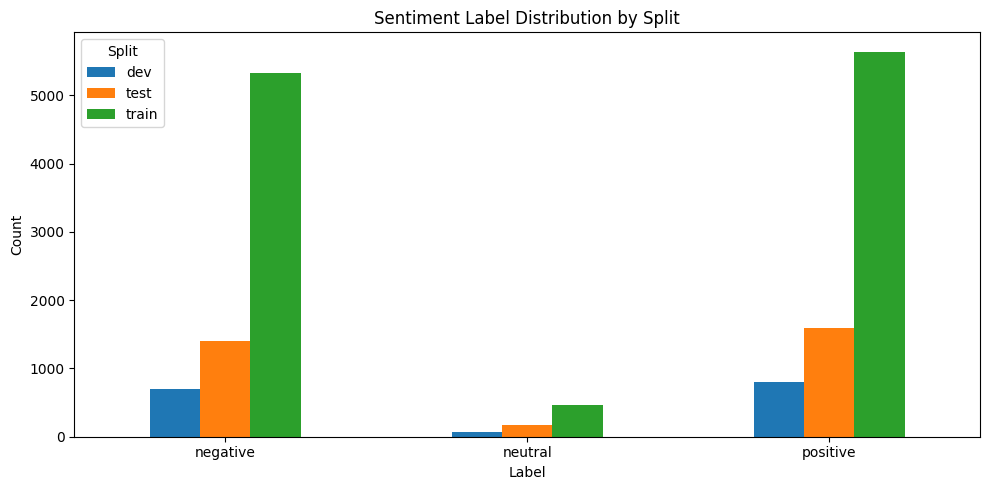

Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\figures\sentiment_distribution.png


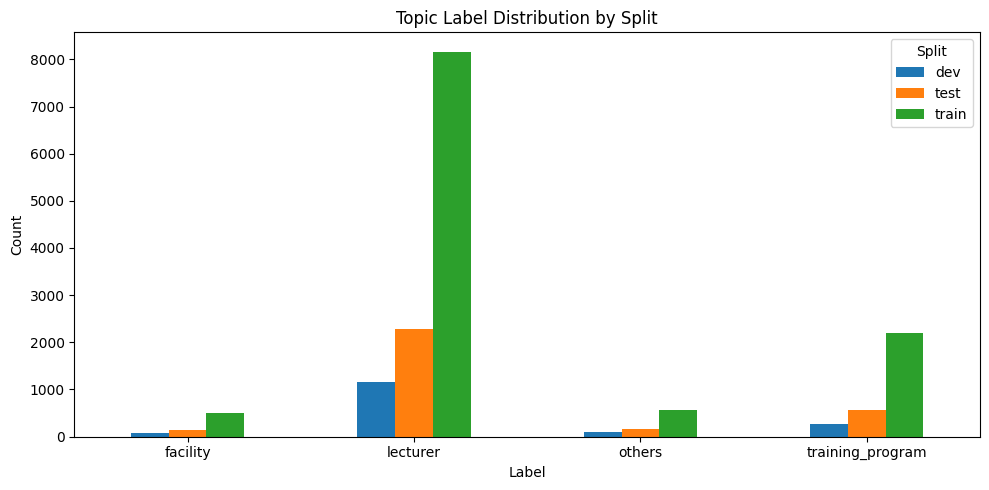

Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\figures\topic_distribution.png


In [16]:
def plot_label_distribution(
    distribution_df: pd.DataFrame,
    title: str,
    output_path: Path,
):
    """Plot label distribution by split."""
    if distribution_df is None or distribution_df.empty:
        print("No data to plot:", title)
        return

    pivot_df = distribution_df.pivot_table(
        index="label",
        columns="split",
        values="count",
        aggfunc="sum",
        fill_value=0,
    )

    ax = pivot_df.plot(kind="bar", figsize=(10, 5))
    ax.set_title(title)
    ax.set_xlabel("Label")
    ax.set_ylabel("Count")
    ax.legend(title="Split")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()

    print("Saved:", output_path)


if sentiment_dist is not None:
    plot_label_distribution(
        sentiment_dist,
        title="Sentiment Label Distribution by Split",
        output_path=FIGURES_DIR / "sentiment_distribution.png",
    )

if topic_dist is not None:
    plot_label_distribution(
        topic_dist,
        title="Topic Label Distribution by Split",
        output_path=FIGURES_DIR / "topic_distribution.png",
    )


## 16. Text length summary

In [17]:
length_columns = ["char_count", "raw_word_count"]

length_summary_rows = []

for split, df in processed_frames.items():
    for col in length_columns:
        values = df[col].dropna()

        length_summary_rows.append({
            "split": split,
            "metric": col,
            "mean": round(values.mean(), 2),
            "median": round(values.median(), 2),
            "p75": round(values.quantile(0.75), 2),
            "p90": round(values.quantile(0.90), 2),
            "p95": round(values.quantile(0.95), 2),
            "p99": round(values.quantile(0.99), 2),
            "max": int(values.max()),
        })

length_summary = pd.DataFrame(length_summary_rows)
length_summary_path = TABLES_DIR / "text_length_summary.csv"
length_summary.to_csv(length_summary_path, index=False, encoding="utf-8-sig")

display(length_summary)
print("Saved:", length_summary_path)


,split,metric,mean,median,p75,p90,p95,p99,max
0,train,char_count,59.08,47.0,73.0,110.0,141.0,218.75,660
1,train,raw_word_count,14.31,11.0,17.0,26.0,33.0,52.00,159
2,dev,char_count,56.36,45.0,69.0,105.8,132.0,196.18,718
3,dev,raw_word_count,13.67,11.0,17.0,25.0,31.0,46.00,161
4,test,char_count,58.84,46.0,73.0,111.0,147.0,221.35,411
5,test,raw_word_count,14.22,11.0,17.0,26.0,34.0,52.35,98


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\text_length_summary.csv


## 17. Text length charts

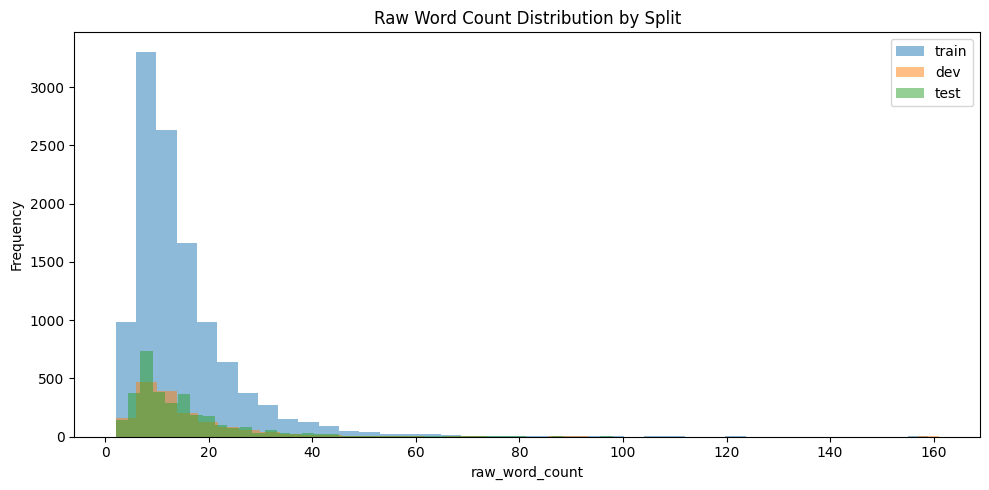

Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\figures\raw_word_count_distribution.png


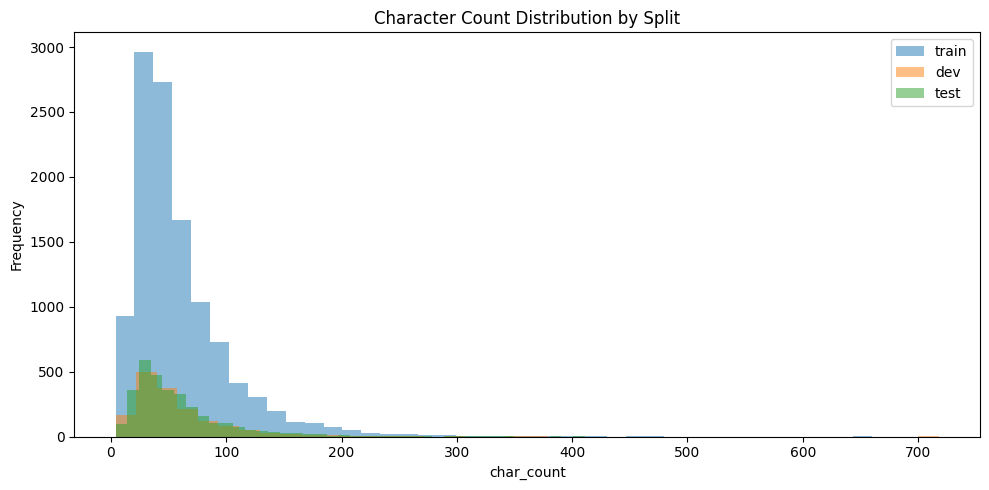

Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\figures\char_count_distribution.png


In [18]:
def plot_histogram_by_split(
    frames: dict[str, pd.DataFrame],
    column: str,
    title: str,
    output_path: Path,
    bins: int = 40,
):
    """Plot a histogram for a numeric column across splits."""
    plt.figure(figsize=(10, 5))

    for split, df in frames.items():
        plt.hist(
            df[column].dropna(),
            bins=bins,
            alpha=0.5,
            label=split,
        )

    plt.title(title)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()

    print("Saved:", output_path)


plot_histogram_by_split(
    processed_frames,
    column="raw_word_count",
    title="Raw Word Count Distribution by Split",
    output_path=FIGURES_DIR / "raw_word_count_distribution.png",
)

plot_histogram_by_split(
    processed_frames,
    column="char_count",
    title="Character Count Distribution by Split",
    output_path=FIGURES_DIR / "char_count_distribution.png",
)


## 18. Preliminary PhoBERT tokenizer length analysis

This is only a preliminary sample-based check. Full segmentation/tokenization analysis is done in a later stage.


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

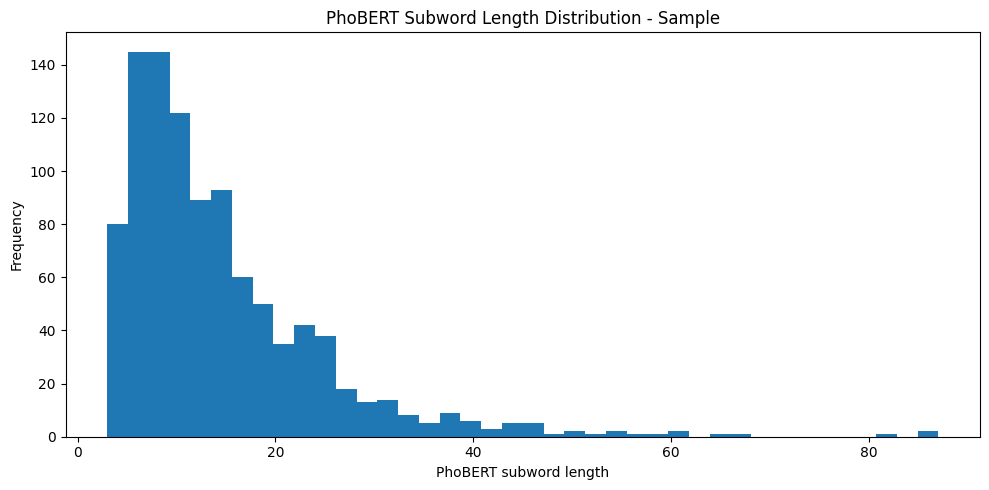

,sample_size,mean,median,p75,p90,p95,p99,max
0,1000,14.62,12.0,18.0,27.0,34.0,55.0,87


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\phobert_subword_length_summary_sample.csv
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\figures\phobert_subword_length_distribution_sample.png


In [19]:
subword_analysis_available = False
subword_error_message = None

try:
    from transformers import AutoTokenizer

    tokenizer = AutoTokenizer.from_pretrained(
        "vinai/phobert-base",
        use_fast=False,
    )

    sample_size = min(1000, len(all_data))
    subword_sample = all_data.sample(sample_size, random_state=SEED).copy()

    def count_phobert_subwords(text: str) -> int:
        """Count PhoBERT subword tokens for one text."""
        return len(tokenizer.tokenize(str(text)))

    subword_sample["phobert_subword_len"] = subword_sample["text"].apply(
        count_phobert_subwords
    )

    subword_summary = pd.DataFrame([{
        "sample_size": sample_size,
        "mean": round(subword_sample["phobert_subword_len"].mean(), 2),
        "median": round(subword_sample["phobert_subword_len"].median(), 2),
        "p75": round(subword_sample["phobert_subword_len"].quantile(0.75), 2),
        "p90": round(subword_sample["phobert_subword_len"].quantile(0.90), 2),
        "p95": round(subword_sample["phobert_subword_len"].quantile(0.95), 2),
        "p99": round(subword_sample["phobert_subword_len"].quantile(0.99), 2),
        "max": int(subword_sample["phobert_subword_len"].max()),
    }])

    subword_summary_path = TABLES_DIR / "phobert_subword_length_summary_sample.csv"
    subword_summary.to_csv(subword_summary_path, index=False, encoding="utf-8-sig")

    plt.figure(figsize=(10, 5))
    plt.hist(subword_sample["phobert_subword_len"], bins=40)
    plt.title("PhoBERT Subword Length Distribution - Sample")
    plt.xlabel("PhoBERT subword length")
    plt.ylabel("Frequency")
    plt.tight_layout()

    subword_fig_path = FIGURES_DIR / "phobert_subword_length_distribution_sample.png"
    plt.savefig(subword_fig_path, dpi=150)
    plt.show()

    subword_analysis_available = True

    display(subword_summary)
    print("Saved:", subword_summary_path)
    print("Saved:", subword_fig_path)

except Exception as error:
    subword_error_message = str(error)
    print("PhoBERT tokenizer analysis was skipped.")
    print("Reason:", subword_error_message)


## 19. Generate dataset schema report

The report is written in English and saved to `reports/notes/dataset_schema_report.md`.


In [20]:
def dataframe_to_markdown(df: pd.DataFrame) -> str:
    """Convert a small DataFrame to a markdown table without requiring tabulate."""
    if df.empty:
        return "_Empty table_"

    safe_df = df.copy().astype(str)
    headers = safe_df.columns.tolist()

    lines = []
    lines.append("| " + " | ".join(headers) + " |")
    lines.append("| " + " | ".join(["---"] * len(headers)) + " |")

    for _, row in safe_df.iterrows():
        lines.append("| " + " | ".join(row[col] for col in headers) + " |")

    return "\n".join(lines)


topic_available = "topic_label" in all_data.columns
sentiment_available = "sentiment_label" in all_data.columns

if topic_available:
    task_decision = "Proceed with sentiment and topic classification."
else:
    task_decision = (
        "Proceed with sentiment classification only for now. "
        "Topic classification requires a reliable topic label or annotation file."
    )

report_lines = []

report_lines.append("# Dataset Schema Report\n")
report_lines.append(f"- Dataset name: `{DATASET_NAME}`")
report_lines.append(f"- Checked at: `{datetime.now().isoformat(timespec='seconds')}`")
report_lines.append(f"- Project root: `{PROJECT_ROOT}`\n")

report_lines.append("## Available splits\n")
report_lines.append(dataframe_to_markdown(split_summary))
report_lines.append("\n")

report_lines.append("## Raw columns by split\n")
for split_name, df in raw_frames.items():
    report_lines.append(f"### {split_name}")
    report_lines.append(f"- Shape: `{df.shape}`")
    report_lines.append(f"- Columns: `{df.columns.tolist()}`\n")

report_lines.append("## Selected project schema\n")
schema_table = pd.DataFrame([
    {"project_field": "text", "source_column": TEXT_COLUMN},
    {"project_field": "sentiment_label", "source_column": SENTIMENT_COLUMN},
    {"project_field": "topic_label", "source_column": TOPIC_COLUMN},
])
report_lines.append(dataframe_to_markdown(schema_table))
report_lines.append("\n")

report_lines.append("## Label mapping\n")
report_lines.append("```json")
report_lines.append(json.dumps(label_mapping, ensure_ascii=False, indent=2))
report_lines.append("```\n")

report_lines.append("## Missing values\n")
report_lines.append(dataframe_to_markdown(missing_summary))
report_lines.append("\n")

report_lines.append("## Duplicate summary\n")
report_lines.append("```json")
report_lines.append(json.dumps(duplicate_summary, ensure_ascii=False, indent=2))
report_lines.append("```\n")

report_lines.append("## Label availability\n")
report_lines.append(f"- Sentiment label available: `{sentiment_available}`")
report_lines.append(f"- Topic label available: `{topic_available}`\n")

report_lines.append("## Preliminary PhoBERT tokenizer length analysis\n")
report_lines.append(f"- Available: `{subword_analysis_available}`")
if not subword_analysis_available:
    report_lines.append(f"- Error: `{subword_error_message}`")
report_lines.append("\n")

report_lines.append("## Stage 1 decision\n")
report_lines.append(task_decision)
report_lines.append("\n")

report_path = NOTES_DIR / "dataset_schema_report.md"

with open(report_path, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))

print("Saved:", report_path)
print("\nStage 1 decision:")
print(task_decision)


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\notes\dataset_schema_report.md

Stage 1 decision:
Proceed with sentiment and topic classification.


## 20. Final Stage 1 output check

In [21]:
expected_files = [
    CONFIG_DIR / "label_mapping.json",
    TABLES_DIR / "split_summary.csv",
    TABLES_DIR / "missing_summary.csv",
    TABLES_DIR / "text_length_summary.csv",
    NOTES_DIR / "dataset_schema_report.md",
]

for split in processed_frames.keys():
    expected_files.append(PROCESSED_DIR / f"{split}.csv")

print("Stage 1 output check:")

all_ok = True

for file_path in expected_files:
    exists = file_path.exists()
    all_ok = all_ok and exists
    print("[OK]     " if exists else "[MISSING]", file_path)

print("\nStage 1 completed:", all_ok)


Stage 1 output check:
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\configs\label_mapping.json
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\split_summary.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\missing_summary.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\text_length_summary.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\notes\dataset_schema_report.md
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\data\processed\train.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\data\processed\dev.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\data\processed\test.csv

Stage 1 completed: True


## What to send for review

After running this notebook from top to bottom, send these outputs for review:

1. Dataset object and available splits.
2. `PROJECT_SCHEMA`.
3. `label_mapping.json` content.
4. Final Stage 1 decision.

Do not proceed to baseline modeling until the dataset schema and label mapping are verified.
